In [1]:
# Standard library imports
import os
import random
import sys
from itertools import product

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib
plt.style.use('../fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('../src/')
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Project imports
from gaugefixer.features import get_additive_features
from gaugefixer.fixers import fix_additive_model
from gaugefixer.verify import verify_identical_evaluation, verify_marginalization
from gaugefixer.sequence import SeqEmbedder, get_alphabet, evaluate_model_on_seqs, randseqs 

In [2]:
# Plot parameters
def plot_additive_thetas(theta_series, fixed_theta_series):
    for order in range(2)[::-1]:
        ix = [len(orbit)==order for orbit,_ in theta_series.index]
        plt.scatter(theta_series[ix], fixed_theta_series[ix], marker='.', label=f'{order=}')
    plt.xlabel('theta_series')
    plt.ylabel('fixed_theta_series')
    plt.legend()
    print(f'features match: {all(theta_series.index == fixed_theta_series.index)}')

N=81
000 f=-9.137323 	 f_fixed=-9.137323, Passed
001 f=-11.173581 	 f_fixed=-11.173581, Passed
002 f=-2.643995 	 f_fixed=-2.643995, Passed
003 f=-1.379203 	 f_fixed=-1.379203, Passed
004 f=-8.492466 	 f_fixed=-8.492466, Passed
005 f=-3.439607 	 f_fixed=-3.439607, Passed
006 f=-8.932978 	 f_fixed=-8.932978, Passed
007 f=-5.702301 	 f_fixed=-5.702301, Passed
008 f=-6.646851 	 f_fixed=-6.646851, Passed
009 f=0.576543 	 f_fixed=0.576543, Passed
010 f=-6.901954 	 f_fixed=-6.901954, Passed
011 f=-5.691744 	 f_fixed=-5.691744, Passed
012 f=-6.151224 	 f_fixed=-6.151224, Passed
013 f=1.428043 	 f_fixed=1.428043, Passed
014 f=-2.921466 	 f_fixed=-2.921466, Passed
015 f=-3.729354 	 f_fixed=-3.729354, Passed
016 f=-11.755272 	 f_fixed=-11.755272, Passed
017 f=-9.173802 	 f_fixed=-9.173802, Passed
018 f=-9.641748 	 f_fixed=-9.641748, Passed
019 f=-2.292596 	 f_fixed=-2.292596, Passed
020 f=-6.316084 	 f_fixed=-6.316084, Passed
021 f=-5.963089 	 f_fixed=-5.963089, Passed
022 f=-8.697102 	 f_fixed=-

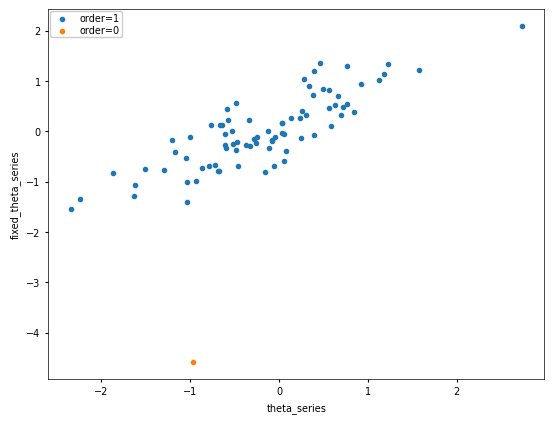

In [3]:
L = 20
alphabet = get_alphabet('dna')
alpha = len(alphabet)
features = get_additive_features(L=L, alphabet=alphabet)
N = len(features)
print(f'{N=:,}')

# Create theta_series
theta_series = pd.Series(index=features,
                         data=np.random.normal(size=N))



# Fix gauge
fixed_theta_series = fix_additive_model(theta=theta_series,
                                        L=L, 
                                        alphabet=alphabet,
                                        gauge='zero-sum')

# Test result
verify_identical_evaluation(theta1=theta_series, 
                            theta2=fixed_theta_series, 
                            L=L, 
                            alphabet=alphabet)

# Plot resulting parameters
plot_additive_thetas(theta_series=theta_series, fixed_theta_series=fixed_theta_series)

In [4]:
random_seqs = randseqs(num_seqs=100, L=L, alphabet=alphabet)
embedder = SeqEmbedder(features=features, L=L)
evaluate_model_on_seqs(theta=theta_series,
                       seqs=random_seqs, embedder=embedder)

array([ -2.41608126,  -7.6578531 ,   2.31656961,  -0.4536909 ,
        -2.0420291 ,  -4.72835735,  -0.81750238,  -0.22144165,
        -6.96021285,  -7.64596204,  -0.7353104 ,  -6.2776669 ,
       -10.36669414,  -4.20172821,  -3.0885848 ,  -6.24356415,
        -6.37653957,  -9.84970129,   3.87334602, -11.10200215,
        -1.78123936,  -7.05635883,  -4.07515044,  -3.11151482,
        -5.21633766,  -7.06082315,  -3.62248683, -11.35709209,
        -8.33532412,  -4.44845745,  -5.13738643,  -3.92611694,
        -5.84941976,  -7.07101005,   0.83093991,   0.68783835,
        -3.8483375 ,  -2.65498439,  -8.51789095,  -2.01214257,
        -4.28498598,  -2.68730019,  -6.05435971,  -9.52966727,
        -0.97814468,  -3.79252798,  -5.9441266 ,  -7.00253315,
        -5.77346123,  -7.30841742,  -5.12374359,  -2.73495534,
        -5.81990775,  -4.4673635 ,   0.39084403,  -7.67195771,
         0.15618149,  -8.42465233,  -2.32206941,  -8.03042222,
        -1.65786178,  -2.53738585,  -0.58496934,  -0.31